# Experiment B - MPJPE vs flow_period (Flow+KF only)

Loads all generated CSVs across all sequences and computes:
- per-sequence MPJPE
- dataset-level MPJPE (weighted by number of frames)

Fixed condition:
- `network_period = ?? s` (?? Hz)

Outputs:
- `results/summary/mpjpe_per_sequence.csv`
- `results/summary/mpjpe_table.csv`
- `plots/mpjpe_vs_flow_period.png`

Paper sentence:

> “We fix the detection period to 50 ms (20 Hz) in the flow-period study because it yields 10 output steps between detections at 200 Hz, creating a non-trivial interpolation interval while avoiding the long-horizon drift regime.”

In [10]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from datasets.utils import constants as ds_constants, parsing as ds_parsing


In [11]:
EXP_DIR = Path('/home/moveEnetFlow/experiments/expB_accuracy_vs_flow_period')
RAW_DIR = EXP_DIR / 'results' / 'raw'
SUMMARY_DIR = EXP_DIR / 'results' / 'summary'
PLOTS_DIR = EXP_DIR / 'plots'

# Must match the --data_root used in run_experiment_b.sh
DATA_ROOT = Path('/data/moveEnet_test/raw')

SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Flow periods to test (must match FLOW_PERIODS in run_experiment_b.sh)
period_tokens = ['0.001', '0.002', '0.005', '0.01', '0.02', '0.05', '0.1']
period_values = [float(x) for x in period_tokens]

print('DATA_ROOT:', DATA_ROOT)
print('RAW_DIR:', RAW_DIR)
print('Flow periods:', period_values)
print('Fixed network_period (s):', 0.1)

DATA_ROOT: /data/moveEnet_test/raw
RAW_DIR: /home/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/results/raw
Flow periods: [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
Fixed network_period (s): 0.1


In [12]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'

def period_to_tag(period_token: str) -> str:
    """Convert period string to filename-safe tag (e.g., '0.001' -> '0p001')."""
    return period_token.replace('.', 'p')

def tag_to_period(tag: str) -> float:
    """Convert filename tag back to period value (e.g., '0p001' -> 0.001)."""
    return float(tag.replace('p', '.'))

def load_pred_eval_csv(csv_path: Path):
    """Load prediction CSV and extract timestamps + 13x2 joint coordinates."""
    arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')
    ts = arr[:, 0]
    joints = arr[:, 2:28].reshape(-1, 13, 2)
    return ts, joints

def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray):
    """Interpolate GT joints to prediction timestamps."""
    ts_gt_raw = np.asarray(gt_data['ts'])
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))
    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)
    for j, joint in enumerate(joint_names):
        x_raw = gt_data[joint][:, 0]
        y_raw = gt_data[joint][:, 1]
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)
    return joints_gt

def extract_metadata_from_name(csv_path: Path):
    """Expected format: sequence__moveenet_ofk_fp_<tag>.csv"""
    name = csv_path.name
    m = re.match(r'(.+)__(moveenet_ofk)_fp_(\d+p\d+|\d+)\.csv$', name)
    if not m:
        raise ValueError(f'Unrecognized filename format: {name}')
    seq_key, _, fp_tag = m.groups()
    method = 'MoveEnet + OFK'
    flow_period_s = tag_to_period(fp_tag)
    return seq_key, method, flow_period_s

def gt_path_from_seq_key(seq_key: str):
    """Map encoded sequence key back to GT skeleton file path."""
    rel = seq_key.replace('__', '/') if '__' in seq_key else seq_key
    return DATA_ROOT / rel / 'ch0GT200Hzskeleton' / 'data.log'

In [13]:
csv_files = sorted(RAW_DIR.glob('fp_*/*.csv'))
print(f'Found {len(csv_files)} prediction CSV files')
if len(csv_files) == 0:
    raise RuntimeError('No CSV files found. Run run_experiment_b.sh first.')

gt_cache = {}
rows = []

for csv_path in csv_files:
    seq_key, method, flow_period_s = extract_metadata_from_name(csv_path)

    gt_path = gt_path_from_seq_key(seq_key)
    if not gt_path.exists():
        print(f'Skipping (missing GT): {gt_path}')
        continue

    if gt_path not in gt_cache:
        gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
    gt_data = gt_cache[gt_path]

    ts_pred, joints_pred = load_pred_eval_csv(csv_path)
    joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

    err = np.linalg.norm(joints_pred - joints_gt, axis=2)  # [N,13]
    per_joint = err.mean(axis=0)
    mpjpe_px = float(per_joint.mean())
    n_samples = int(err.shape[0])

    rows.append({
        'sequence': seq_key,
        'method': method,
        'flow_period_s': flow_period_s,
        'flow_rate_hz': 1.0 / flow_period_s,
        'network_period_s': 0.05,
        'detection_rate_hz': 20.0,
        'n_samples': n_samples,
        'sum_err_px': float(err.sum()),
        'n_points': int(err.size),
        'mpjpe_px': mpjpe_px,
        **{f'mpjpe_{joint}': float(per_joint[i]) for i, joint in enumerate(joint_names)}
    })

df_seq = pd.DataFrame(rows).sort_values(['flow_period_s', 'sequence']).reset_index(drop=True)
print('Per-sequence rows:', len(df_seq))

hidden_cols = ['n_samples', 'sum_err_px', 'n_points']
visible_df = df_seq.drop(columns=hidden_cols, errors='ignore')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(visible_df)

Found 105 prediction CSV files
Per-sequence rows: 105


,sequence,method,flow_period_s,flow_rate_hz,network_period_s,detection_rate_hz,mpjpe_px,mpjpe_head,mpjpe_shoulder_right,mpjpe_shoulder_left,mpjpe_elbow_right,mpjpe_elbow_left,mpjpe_hip_left,mpjpe_hip_right,mpjpe_wrist_right,mpjpe_wrist_left,mpjpe_knee_right,mpjpe_knee_left,mpjpe_ankle_right,mpjpe_ankle_left
0,cam2_S1_Directions,MoveEnet + OFK,0.001,1000.0,0.05,20.0,6.005840,4.203603,4.552221,4.009553,8.428101,5.988544,4.615124,3.851539,12.483244,12.027856,3.627739,3.170331,6.904307,4.213765
1,cam2_S1_Discussion,MoveEnet + OFK,0.001,1000.0,0.05,20.0,6.197387,3.329927,3.355254,4.327905,6.237884,6.903751,4.204518,4.190290,12.844504,13.462037,4.695301,4.822043,6.565731,5.626889
2,cam2_S1_Eating,MoveEnet + OFK,0.001,1000.0,0.05,20.0,7.278582,3.978894,4.797557,4.022674,6.561972,7.020298,5.308283,5.455052,10.541428,12.264619,6.967201,7.820793,8.634211,11.248579
3,cam2_S1_Greeting,MoveEnet + OFK,0.001,1000.0,0.05,20.0,6.835920,5.132077,3.548776,4.478379,7.188632,7.686891,3.970560,4.104195,14.632091,15.020123,4.229029,4.462557,7.056264,7.357377
4,cam2_S1_Phoning,MoveEnet + OFK,0.001,1000.0,0.05,20.0,7.356387,4.314213,5.691880,4.934271,7.177093,6.236775,5.300461,4.930993,12.243635,9.740953,7.220572,7.971991,9.270182,10.600014
5,cam2_S1_Posing,MoveEnet + OFK,0.001,1000.0,0.05,20.0,5.993557,3.303339,4.414061,4.097877,5.569384,5.078575,4.469882,3.996247,12.112215,10.004215,4.790582,3.829782,8.052422,8.197658
6,cam2_S1_Purchases,MoveEnet + OFK,0.001,1000.0,0.05,20.0,7.551087,6.096380,5.979047,6.568513,8.081298,6.564150,6.743864,6.267407,13.163499,10.058486,5.347315,5.908258,7.643441,9.742467
7,cam2_S1_SittingDown,MoveEnet + OFK,0.001,1000.0,0.05,20.0,8.663148,5.329101,4.777447,5.808025,8.022295,9.133074,6.934444,6.389366,12.059227,11.087242,9.933924,11.903689,10.087463,11.155622
8,cam2_S1_Sitting_1,MoveEnet + OFK,0.001,1000.0,0.05,20.0,8.036930,4.521284,4.357264,5.057707,7.503886,7.628125,6.079311,5.796817,13.610123,14.209849,6.964925,8.943387,9.732252,10.075159
9,cam2_S1_Smoking,MoveEnet + OFK,0.001,1000.0,0.05,20.0,7.503506,3.567465,5.336067,4.259447,8.515715,6.750539,5.421438,6.469009,12.237603,11.160656,7.248513,6.870507,10.042180,9.666440


In [14]:
if len(df_seq) == 0:
    raise RuntimeError('No valid sequence rows to aggregate.')

agg = (
    df_seq.groupby(['flow_period_s', 'flow_rate_hz', 'method'], as_index=False)
    .agg(sum_err_px=('sum_err_px', 'sum'), n_points=('n_points', 'sum'), n_samples=('n_samples', 'sum'))
)
agg['mpjpe_px'] = agg['sum_err_px'] / agg['n_points']
df_table = agg.sort_values(['flow_period_s']).reset_index(drop=True)

per_seq_path = SUMMARY_DIR / 'mpjpe_per_sequence.csv'
table_path = SUMMARY_DIR / 'mpjpe_table.csv'
df_seq.to_csv(per_seq_path, index=False)
df_table.to_csv(table_path, index=False)

print('Saved:', per_seq_path)
print('Saved:', table_path)

display(df_table[['flow_period_s', 'flow_rate_hz', 'method', 'mpjpe_px']])

Saved: /home/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/results/summary/mpjpe_per_sequence.csv
Saved: /home/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/results/summary/mpjpe_table.csv


,flow_period_s,flow_rate_hz,method,mpjpe_px
0,0.001,1000.0,MoveEnet + OFK,7.236823
1,0.002,500.0,MoveEnet + OFK,7.243947
2,0.005,200.0,MoveEnet + OFK,7.251215
3,0.010,100.0,MoveEnet + OFK,7.239800
4,0.020,50.0,MoveEnet + OFK,7.252576
5,0.050,20.0,MoveEnet + OFK,7.238202
6,0.100,10.0,MoveEnet + OFK,7.564665


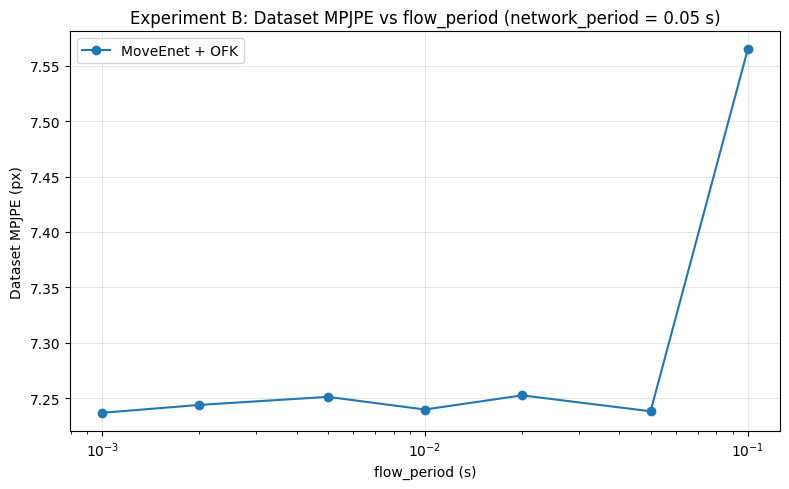

Saved: /home/moveEnetFlow/experiments/expB_accuracy_vs_flow_period/plots/mpjpe_vs_flow_period.png


In [15]:
plt.figure(figsize=(8, 5))
d = df_table[df_table['method'] == 'MoveEnet + OFK'].sort_values('flow_period_s')

plt.plot(d['flow_period_s'], d['mpjpe_px'], marker='o', label='MoveEnet + OFK')
plt.xscale('log')
plt.xlabel('flow_period (s)')
plt.ylabel('Dataset MPJPE (px)')
plt.title('Experiment B: Dataset MPJPE vs flow_period (network_period = 0.05 s)')
plt.grid(True, alpha=0.3)
plt.legend()
plot1 = PLOTS_DIR / 'mpjpe_vs_flow_period.png'
plt.tight_layout()
plt.savefig(plot1, dpi=180)
plt.show()
print('Saved:', plot1)

In [16]:
# Optional: inspect where MPJPE starts increasing sharply ("knee").
d = df_table[df_table['method'] == 'MoveEnet + OFK'].sort_values('flow_period_s').copy()
d['delta_mpjpe_px'] = d['mpjpe_px'].diff()
display(d[['flow_period_s', 'flow_rate_hz', 'mpjpe_px', 'delta_mpjpe_px']])

,flow_period_s,flow_rate_hz,mpjpe_px,delta_mpjpe_px
0,0.001,1000.0,7.236823,NaN
1,0.002,500.0,7.243947,0.007124
2,0.005,200.0,7.251215,0.007267
3,0.010,100.0,7.239800,-0.011414
4,0.020,50.0,7.252576,0.012775
5,0.050,20.0,7.238202,-0.014374
6,0.100,10.0,7.564665,0.326464
